file di analisi per dead zones, dati simulati con G4

In [25]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import h5py
from pathlib import Path
import sys
from library import propagazione_errore


# RESULT_ROOT = Path('/home/matti/uni/lab/Lab-muons/simulazioni/tia/g4/results/mgp')
RESULT_ROOT = (Path.cwd().parent / "g4" / "results" / "mgp").resolve()


def result_path(folder, number):
    return (
        RESULT_ROOT / folder / f'{number}.h5',
        # RESULT_ROOT / folder / f'run_{number}.h5',
    )


def count_hits(h5_paths, chunk_size=100_000):
    """Count detector coincidences from paired HDF5 files in chunks."""
    count_both = 0
    count_all_three = 0

    for h5_path in h5_paths:
        with h5py.File(h5_path, 'r') as file:
            data = file['data']
            row_count = len(data['HitBottom'])
            for start in range(0, row_count, chunk_size):
                stop = min(start + chunk_size, row_count)
                hit_bottom = data['HitBottom'][start:stop]
                hit_top = data['HitTop'][start:stop]
                hit_middle = data['HitMiddle'][start:stop]

                both = (hit_bottom == 1) & (hit_top == 1)
                all_three = both & (hit_middle == 1)
                count_both += int(both.sum())
                count_all_three += int(all_three.sum())

    return count_both, count_all_three


frac = lambda val: propagazione_errore(["a", "b"] , "a/b" , val , [[np.sqrt(val[0]) , 0] , [0 , np.sqrt(val[1])]] , Display=False)

# cos

In [26]:
mgp0_m = result_path('1cm_minerva_C', 0)
mgp0_p = result_path('1cm_minerva_C', 1)
mgp15_m = result_path('1cm_minerva_C', 2)
mgp15_p = result_path('1cm_minerva_C', 3)
mgp30_m = result_path('1cm_minerva_C', 4)
mgp30_p = result_path('1cm_minerva_C', 5)
mgp45_m = result_path('1cm_minerva_C', 6)
mgp45_p = result_path('1cm_minerva_C', 7)
mgp60_m = result_path('1cm_minerva_C', 8)
mgp60_p = result_path('1cm_minerva_C', 9)

In [27]:
d0m, t0m = count_hits(mgp0_m)
d0p, t0p = count_hits(mgp0_p)
d15m, t15m = count_hits(mgp15_m)
d15p, t15p = count_hits(mgp15_p)
d30m, t30m = count_hits(mgp30_m)
d30p, t30p = count_hits(mgp30_p)
d45m, t45m = count_hits(mgp45_m)
d45p, t45p = count_hits(mgp45_p)
d60m, t60m = count_hits(mgp60_m)
d60p, t60p = count_hits(mgp60_p)

In [28]:
print(d0m, t0m)

618665 617937


In [29]:
print (t60m)

10333


In [30]:
print(t0m/d0m, t0p/d0p)
print(t15m/d15m, t15p/d15p)
print(t30m/d30m, t30p/d30p)
print(t45m/d45m, t45p/d45p)
print(t60m/d60m, t60p/d60p)

0.9988232726920062 0.9987852354414022
0.9529891341834084 0.9524209733493155
0.8064062471086767 0.806976701103502
0.6127953544253104 0.6085540685437433
0.5249707869735305 0.5323458282950423


# cos^2

In [31]:
mgp0_ms = result_path('1cm_minerva_c2', 0)
mgp0_ps = result_path('1cm_minerva_c2', 1)
mgp15_ms = result_path('1cm_minerva_c2', 2)
mgp15_ps = result_path('1cm_minerva_c2', 3)
mgp30_ms = result_path('1cm_minerva_c2', 4)
mgp30_ps = result_path('1cm_minerva_c2', 5)
mgp45_ms = result_path('1cm_minerva_c2', 6)
mgp45_ps = result_path('1cm_minerva_c2', 7)
mgp60_ms = result_path('1cm_minerva_c2', 8)
mgp60_ps = result_path('1cm_minerva_c2', 9)

In [32]:
d0ms, t0ms = count_hits(mgp0_ms)
d0ps, t0ps = count_hits(mgp0_ps)
d15ms, t15ms = count_hits(mgp15_ms)
d15ps, t15ps = count_hits(mgp15_ps)
d30ms, t30ms = count_hits(mgp30_ms)
d30ps, t30ps = count_hits(mgp30_ps)
d45ms, t45ms = count_hits(mgp45_ms)
d45ps, t45ps = count_hits(mgp45_ps)
d60ms, t60ms = count_hits(mgp60_ms)
d60ps, t60ps = count_hits(mgp60_ps)

In [33]:
print(t0ms/d0ms, t0ps/d0ps)
print(t15ms/d15ms, t15ps/d15ps)
print(t30ms/d30ms, t30ps/d30ps)
print(t45ms/d45ms, t45ps/d45ps)
print(t60ms/d60ms, t60ps/d60ps)
print(t60ms,d60ms, t60ps,d60ps)
print(t45ms,d45ms, t45ps,d45ps)

0.99913033205374 0.9990844235422572
0.9548345070646673 0.9553690582358337
0.8042291329366331 0.8027776029538255
0.5874310699252782 0.5874760217186331
0.5483870967741935 0.5456642550068156
5321 9703 5204 9537
18003 30647 18069 30757


# cos^1/3

In [34]:
mgp0_m1 = result_path('1cm_minerva_c13', 0)
mgp0_p1 = result_path('1cm_minerva_c13', 1)
mgp15_m1 = result_path('1cm_minerva_c13', 2)
mgp15_p1 = result_path('1cm_minerva_c13', 3)
mgp30_m1 = result_path('1cm_minerva_c13', 4)
mgp30_p1 = result_path('1cm_minerva_c13', 5)
mgp45_m1 = result_path('1cm_minerva_c13', 6)
mgp45_p1 = result_path('1cm_minerva_c13', 7)
mgp60_m1 = result_path('1cm_minerva_c13', 8)
mgp60_p1 = result_path('1cm_minerva_c13', 9)

In [35]:
d0m1, t0m1 = count_hits(mgp0_m1)
d0p1, t0p1 = count_hits(mgp0_p1)
d15m1, t15m1 = count_hits(mgp15_m1)
d15p1, t15p1 = count_hits(mgp15_p1)
d30m1, t30m1 = count_hits(mgp30_m1)
d30p1, t30p1 = count_hits(mgp30_p1)
d45m1, t45m1 = count_hits(mgp45_m1)
d45p1, t45p1 = count_hits(mgp45_p1)
d60m1, t60m1 = count_hits(mgp60_m1)
d60p1, t60p1 = count_hits(mgp60_p1)
print(d60m1, t60m1)

31678 17044


# cos^2/3

In [36]:
mgp0_m2 = result_path('1cm_minerva_c23', 0)
mgp0_p2 = result_path('1cm_minerva_c23', 1)
mgp15_m2 = result_path('1cm_minerva_c23', 2)
mgp15_p2 = result_path('1cm_minerva_c23', 3)
mgp30_m2 = result_path('1cm_minerva_c23', 4)
mgp30_p2 = result_path('1cm_minerva_c23', 5)
mgp45_m2 = result_path('1cm_minerva_c23', 6)
mgp45_p2 = result_path('1cm_minerva_c23', 7)
mgp60_m2 = result_path('1cm_minerva_c23', 8)
mgp60_p2 = result_path('1cm_minerva_c23', 9)

In [37]:
d0m2, t0m2 = count_hits(mgp0_m2)
d0p2, t0p2 = count_hits(mgp0_p2)
d15m2, t15m2 = count_hits(mgp15_m2)
d15p2, t15p2 = count_hits(mgp15_p2)
d30m2, t30m2 = count_hits(mgp30_m2)
d30p2, t30p2 = count_hits(mgp30_p2)
d45m2, t45m2 = count_hits(mgp45_m2)
d45p2, t45p2 = count_hits(mgp45_p2)
d60m2, t60m2 = count_hits(mgp60_m2)
d60p2, t60p2 = count_hits(mgp60_p2)
print(d45m2, d60p2)

58420 25423


# peso

In [38]:
def filtering(a, b, c, d, peso_a = 0.54, peso_c = 0.54):
    filt1 = int(a * peso_a + b *(1-peso_a))
    filt2 = int(c * peso_c + d *(1-peso_c))
    return filt2 / filt1


In [39]:
angles = [0, 15, 30, 45, 60]
variants = ['', 's', '1', '2']  # The suffixes: d0m, d0ms, d0m1, d0m2
polarities = ['m', 'p']

results = {}

for angle in angles:
    results[angle] = {}
    
    for variant in variants:
        # Get both m and p polarities for this angle/variant
        d_m = globals()[f'd{angle}m{variant}']
        t_m = globals()[f't{angle}m{variant}']
        d_p = globals()[f'd{angle}p{variant}']
        t_p = globals()[f't{angle}p{variant}']
        
        # Apply filtering (or store as-is, depending on your logic)
        results[angle][variant] = filtering(d_m, d_p, t_m, t_p)

print(results)

errors = {}

for angle in angles:
    errors[angle] = {}

    for variant in variants:
        d_m = globals()[f'd{angle}m{variant}']
        d_p = globals()[f'd{angle}p{variant}']
        t_m = globals()[f't{angle}m{variant}']
        t_p = globals()[f't{angle}p{variant}']

        filt1 = int(d_m * 0.54 + d_p * 0.46)
        filt2 = int(t_m * 0.54 + t_p * 0.46)

        errors[angle][variant] = frac([filt2, filt1])

print (errors)

{0: {'': 0.9988058341224416, 's': 0.9991094558433781, '1': 0.9982954436266502, '2': 0.9986088049964916}, 15: {'': 0.9527266126215556, 's': 0.9550803411684211, '1': 0.9510587766529132, '2': 0.9514727260852843}, 30: {'': 0.8066688060825239, 's': 0.8035581756822987, '1': 0.8094578219294772, '2': 0.8084713884832861}, 45: {'': 0.6108229943750748, 's': 0.5874515424960094, '1': 0.6300775935533063, '2': 0.6196629405531057}, 60: {'': 0.5283935621014273, 's': 0.5471639310201537, '1': 0.5339097202643862, '2': 0.5338588884509263}}
{0: {'': 6.40480509563017e-5, 's': 5.82215895757344e-5, '1': 7.29151742399334e-5, '2': 6.76011144196714e-5}, 15: {'': 8.10032981363870e-5, 's': 7.65010713346291e-5, '1': 8.93194863007364e-5, '2': 8.41148264171554e-5}, 30: {'': 0.000154096830381193, 's': 0.000169026034432114, '1': 0.000151149366505555, '2': 0.000151234987146650}, 45: {'': 0.000320720790659223, 's': 0.000454614385367904, '1': 0.000262366285717722, '2': 0.000287679859406735}, 60: {'': 0.000601886723344973, 

# plot

importo i dati misurati

In [40]:
default_dir = str(Path(".").absolute()).split("/Lab-muons")[0]+"/Lab-muons/"
universal_dir = lambda path: default_dir + path

DATA_PATH = universal_dir("Data/calibration/dead_zones.csv")


In [41]:
data = pd.read_csv(DATA_PATH, sep=",", header=0)
# print (data)

In [42]:
df_G = data[data['ordine[TtB]'] == 'mgp']
df_P = data[data['ordine[TtB]'] == 'mpg']
df_M = data[data['ordine[TtB]'] == 'gmp']
final_df = pd.read_csv(universal_dir('Data/calibration/efficiency.csv'), delimiter = ',')
partenope = final_df[final_df['ordine[TtB]'] == 'mpg'][[' gm_doppie', ' pgm_triple']].values.tolist()

print(df_P)

  ordine[TtB]  p_distanza[cm]  g_distanza[cm]  m_distanza[cm]   p_count  \
0         mpg               0               0               0      9321   
1         mpg              15               0               0      9478   
2         mpg              30               0               0      9288   
3         mpg              45               0               0      9194   
4         mpg              60               0               0      9472   
5         mpg              75               0               0      9597   

    pm_doppie   gm_doppie   pg_doppie   pgm_triple  tempo[min]  
0        7198        5882         NaN         5784         5.0  
1        6597        5907         NaN         4995         5.0  
2        5363        5877         NaN         3743         5.0  
3        4068        5908         NaN         2503         5.0  
4        2761        6146         NaN         1468         5.0  
5        1402        5896         NaN          362         5.0  


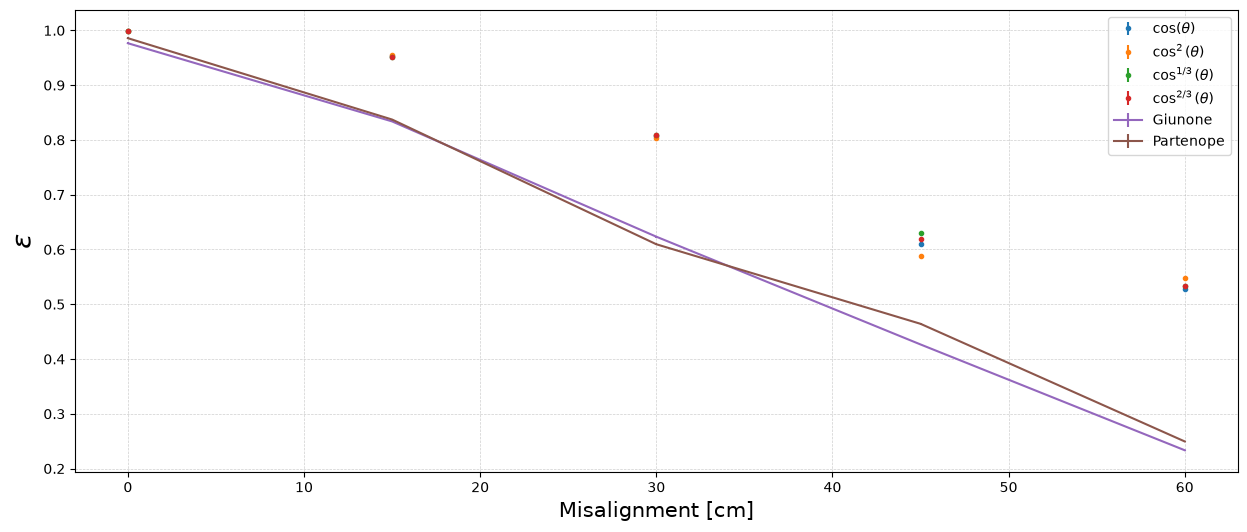

In [43]:
labels = {
    '': r'$\cos(\theta)$',
    's': r'$\cos^{2}(\theta)$',
    '1': r'$\cos^{1/3}(\theta)$',
    '2': r'$\cos^{2/3}(\theta)$'
}

frac = lambda a, b: propagazione_errore(
    ["a", "b"],
    "a/b",
    [a, b],
    [[np.sqrt(a), 0], [0, np.sqrt(b)]],
    Display=False
)

df_filtered = df_G[df_G[' pm_doppie'].notna()]

y_g = ( df_filtered[' pgm_triple'] / df_filtered[' pm_doppie']).iloc[:5].values
err_g = np.array([
    frac(a, b)
    for a, b in zip(df_filtered[' pgm_triple'][:5],
                    df_filtered[' pm_doppie'][:5])
])

df_filtered = df_P[df_P[' gm_doppie'].notna()]
y_p = [pair[1] / pair[0] for pair in partenope]
err_p =  np.array([
    frac(a, b)
    for a, b in zip(df_P[' pgm_triple'][:5],
                    df_P[' gm_doppie'][:5])
])

x = np.linspace( 0, 60, 5)

plt.figure(figsize= (15,6))
for key in ['', 's', '1', '2']:
    y = [results[t][key] for t in x]
    err_y = [errors[t][key] for t in x]
    plt.errorbar(x, y, err_y, label=labels[key], fmt = '.')

plt.errorbar(x, y_g, err_g, label = 'Giunone', )
plt.errorbar(x, y_p, err_p, label = 'Partenope')
plt.ylabel(r'$ \epsilon $', fontsize = 20)
plt.xlabel('Misalignment [cm]', fontsize = 15)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)

# plt.savefig('pg_eff.pdf')

In [44]:
print (err_p)

[0.00208366555388779 0.00189750602808923 0.00163451572697396
 0.00135225668755810 0.00106429979385968]


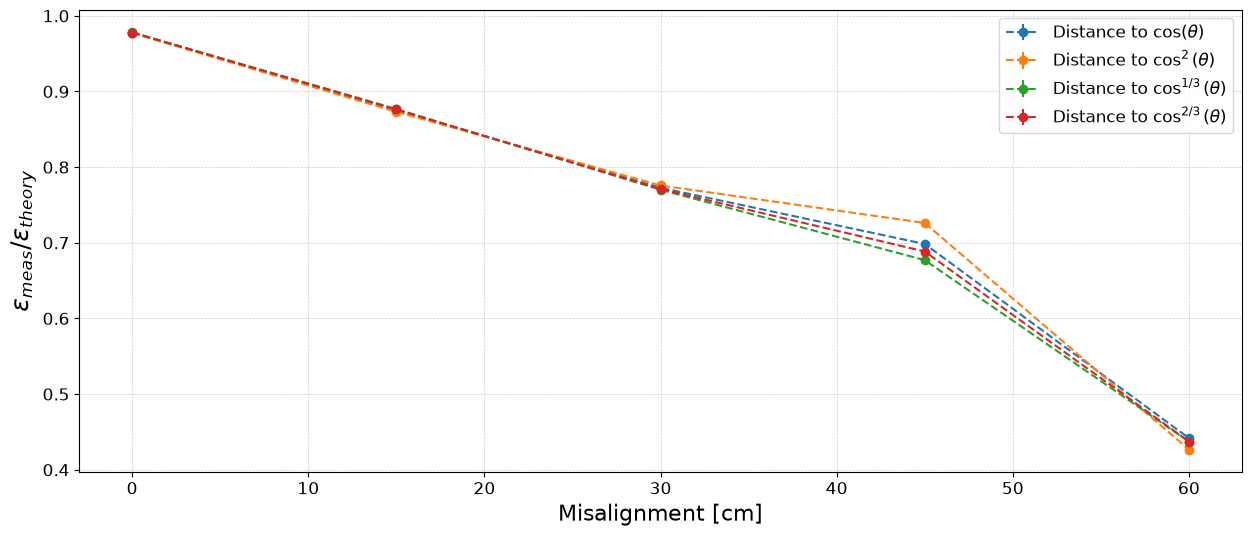

In [45]:

plt.figure(figsize=(15, 6))

# Loop through each of the 4 theoretical models
for key in ['', 's', '1', '2']:
    # Convert ALL arrays to native numpy 64-bit floats to strip SymPy object wrappers
    y_model = np.array([results[t][key] for t in x], dtype=np.float64)
    sigma_model = np.array([errors[t][key] for t in x], dtype=np.float64)
    y_experimental = np.array(y_g, dtype=np.float64)
    err_p_numeric = np.array(err_g, dtype=np.float64)
    
    # Calculate (Experimental - Model) / Sigma safely
    normalized_distance = (y_experimental /y_model)#/ np.sqrt(sigma_model**2 + err_p_numeric**2))
    
    # Plot the normalized distances as points connected by a dashed line
    plt.errorbar(x, normalized_distance, np.sqrt(sigma_model**2 + err_p_numeric**2), marker='o', linestyle='--', label=f"Distance to {labels[key]}")

# --- STYLING THE PLOT ---
plt.ylabel(r'$\epsilon_{meas} / \epsilon_{theory}$', fontsize=18)
plt.xlabel('Misalignment [cm]', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Horizontal line at 0 set to dashed ('--') as requested
# plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Grid explicit configuration
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.xlim(-3, 63)
plt.legend(loc='upper right', fontsize=12)

# plt.show()
plt.savefig('g_eff_dist_m1cm.pdf')

# new try


In [46]:
def result_path(folder, number):
    return (
        RESULT_ROOT / folder / f'{number}.h5',
        # RESULT_ROOT / folder / f'run_{number}.h5',
    )


In [47]:
mgp0_m_75 = result_path('75cmm', 0)
mgp0_p_75 = result_path('75cmm', 1)
mgp15_m_75 = result_path('75cmm', 2)
mgp15_p_75 = result_path('75cmm', 3)
mgp30_m_75 = result_path('75cmm', 4)
mgp30_p_75 = result_path('75cmm', 5)
mgp45_m_75 = result_path('75cmm', 6)
mgp45_p_75 = result_path('75cmm', 7)
mgp60_m_75 = result_path('75cmm', 8)
mgp60_p_75 = result_path('75cmm', 9)

In [48]:
d0m, t0m = count_hits(mgp0_m_75)
d0p, t0p = count_hits(mgp0_p_75)
d15m, t15m = count_hits(mgp15_m_75)
d15p, t15p = count_hits(mgp15_p_75)
d30m, t30m = count_hits(mgp30_m_75)
d30p, t30p = count_hits(mgp30_p_75)
d45m, t45m = count_hits(mgp45_m_75)
d45p, t45p = count_hits(mgp45_p_75)
d60m, t60m = count_hits(mgp60_m_75)
d60p, t60p = count_hits(mgp60_p_75)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/feBolde/coding/Lab-muons/simulazioni/tia/g4/results/mgp/75cmm/0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
cm0 = filtering(d0m, d0p, t0m, t0p)
cm15 = filtering(d15m, d15p, t15m, t15p)
cm30 = filtering(d30m, d30p, t30m, t30p)
cm45 = filtering(d45m, d45p, t45m, t45p)
cm60 = filtering(d60m, d60p, t60m, t60p)

In [ ]:
mgp0_m_73 = result_path('73cm', 0)
mgp0_p_73 = result_path('73cm', 1)
mgp15_m_73 = result_path('73cm', 2)
mgp15_p_73 = result_path('73cm', 3)
mgp30_m_73 = result_path('73cm', 4)
mgp30_p_73 = result_path('73cm', 5)
mgp45_m_73 = result_path('73cm', 6)
mgp45_p_73 = result_path('73cm', 7)
mgp60_m_73 = result_path('73cm', 8)
mgp60_p_73 = result_path('73cm', 9)

d0m_73, t0m_73 = count_hits(mgp0_m_73)
d0p_73, t0p_73 = count_hits(mgp0_p_73)
d15m_73, t15m_73 = count_hits(mgp15_m_73)
d15p_73, t15p_73 = count_hits(mgp15_p_73)
d30m_73, t30m_73 = count_hits(mgp30_m_73)
d30p_73, t30p_73 = count_hits(mgp30_p_73)
d45m_73, t45m_73 = count_hits(mgp45_m_73)
d45p_73, t45p_73 = count_hits(mgp45_p_73)
d60m_73, t60m_73 = count_hits(mgp60_m_73)
d60p_73, t60p_73 = count_hits(mgp60_p_73)

In [ ]:
cm0_73 = filtering(d0m_73, d0p_73, t0m_73, t0p_73)
cm15_73 = filtering(d15m_73, d15p_73, t15m_73, t15p_73)
cm30_73 = filtering(d30m_73, d30p_73, t30m_73, t30p_73)
cm45_73 = filtering(d45m_73, d45p_73, t45m_73, t45p_73)
cm60_73 = filtering(d60m_73, d60p_73, t60m_73, t60p_73)

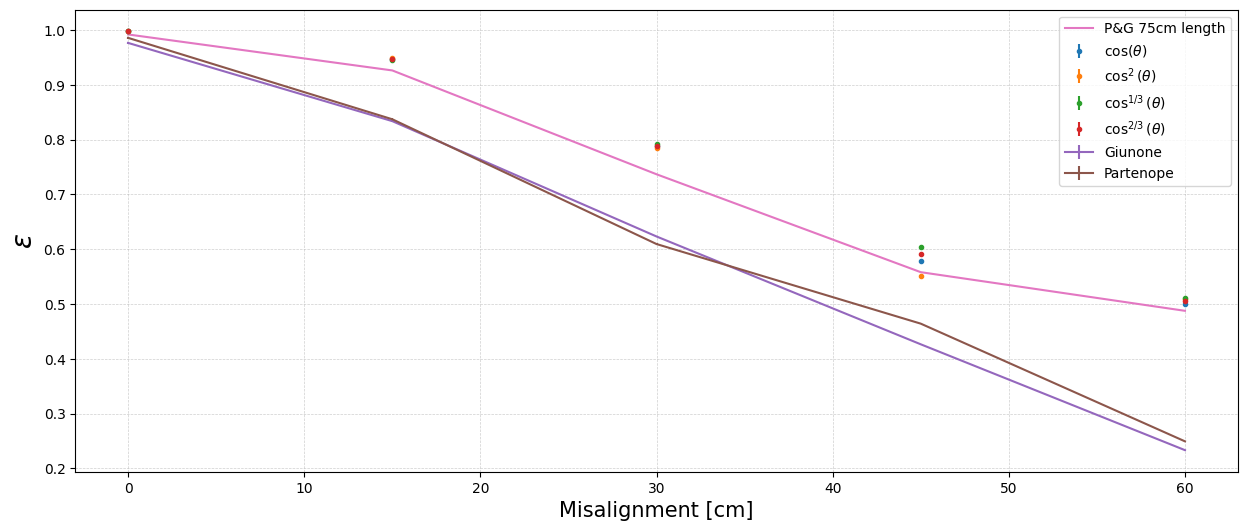

In [ ]:
labels = {
    '': r'$\cos(\theta)$',
    's': r'$\cos^{2}(\theta)$',
    '1': r'$\cos^{1/3}(\theta)$',
    '2': r'$\cos^{2/3}(\theta)$'
}

frac = lambda a, b: propagazione_errore(
    ["a", "b"],
    "a/b",
    [a, b],
    [[np.sqrt(a), 0], [0, np.sqrt(b)]],
    Display=False
)

df_filtered = df_G[df_G[' pm_doppie'].notna()]

y_g = ( df_filtered[' pgm_triple'] / df_filtered[' pm_doppie']).iloc[:5].values
err_g = np.array([
    frac(a, b)
    for a, b in zip(df_filtered[' pgm_triple'][:5],
                    df_filtered[' pm_doppie'][:5])
])

df_filtered = df_P[df_P[' gm_doppie'].notna()]
y_p = [pair[1] / pair[0] for pair in partenope]
err_p =  np.array([
    frac(a, b)
    for a, b in zip(df_P[' pgm_triple'][:5],
                    df_P[' gm_doppie'][:5])
])

x = np.linspace( 0, 60, 5)

plt.figure(figsize= (15,6))
for key in ['', 's', '1', '2']:
    y = [results[t][key] for t in x]
    err_y = [errors[t][key] for t in x]
    plt.errorbar(x, y, err_y, label=labels[key], fmt = '.')

plt.errorbar(x, y_g, err_g, label = 'Giunone', )
plt.errorbar(x, y_p, err_p, label = 'Partenope')
plt.plot(x, (cm0, cm15, cm30, cm45, cm60), label = "P&G 75cm length")
# plt.plot(x, (cm0_73, cm15_73, cm30_73, cm45_73, cm60_73), label = "P&G 73cm length")
plt.ylabel(r'$ \epsilon $', fontsize = 20)
plt.xlabel('Misalignment [cm]', fontsize = 15)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
# 
# plt.savefig('pg_eff.pdf')

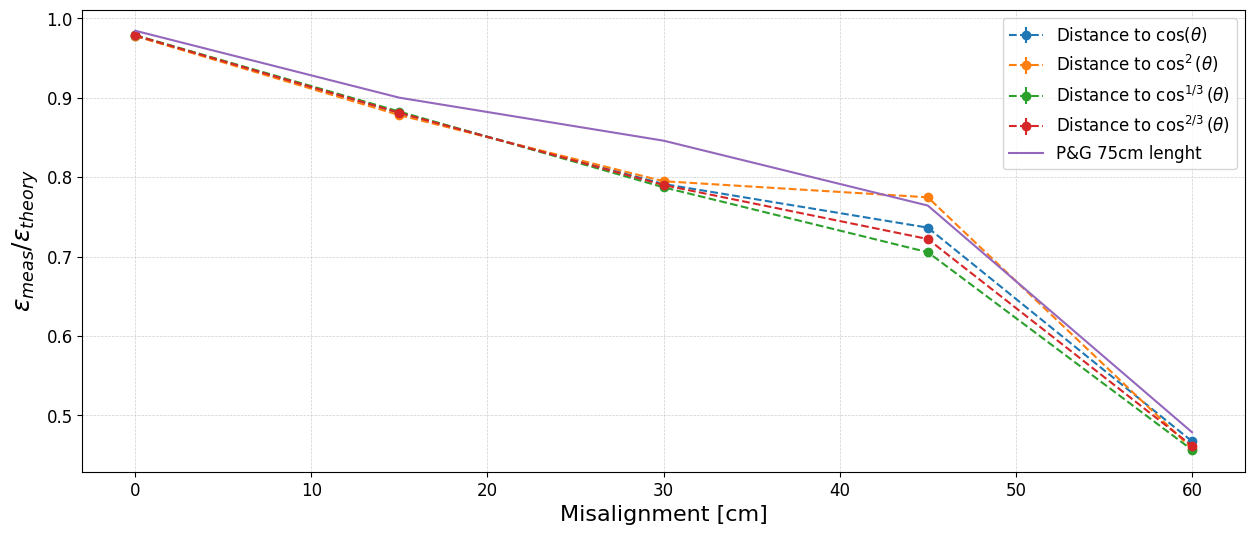

In [ ]:

plt.figure(figsize=(15, 6))

# Loop through each of the 4 theoretical models
for key in ['', 's', '1', '2']:
    # Convert ALL arrays to native numpy 64-bit floats to strip SymPy object wrappers
    y_model = np.array([results[t][key] for t in x], dtype=np.float64)
    sigma_model = np.array([errors[t][key] for t in x], dtype=np.float64)
    y_experimental = np.array(y_g, dtype=np.float64)
    err_p_numeric = np.array(err_g, dtype=np.float64)
    
    # Calculate (Experimental - Model) / Sigma safely
    normalized_distance = (y_experimental /y_model)#/ np.sqrt(sigma_model**2 + err_p_numeric**2))
    
    # Plot the normalized distances as points connected by a dashed line
    plt.errorbar(x, normalized_distance, np.sqrt(sigma_model**2 + err_p_numeric**2), marker='o', linestyle='--', label=f"Distance to {labels[key]}")

# --- STYLING THE PLOT ---
plt.ylabel(r'$\epsilon_{meas} / \epsilon_{theory}$', fontsize=18)
plt.xlabel('Misalignment [cm]', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.errorbar(x, (y_experimental[0]/ cm0, 
                 y_experimental[1]/ cm15, y_experimental[2]/cm30, 
                 y_experimental[3]/ cm45, y_experimental[4]/cm60), label = "P&G 75cm lenght" )

# plt.errorbar(x, (y_experimental[0]/ cm0_73, 
#                  y_experimental[1]/ cm15_73, y_experimental[2]/cm30_73, 
#                  y_experimental[3]/ cm45_73, y_experimental[4]/cm60_73), label = "P&G 73cm lenght" )

# Horizontal line at 0 set to dashed ('--') as requested
# plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Grid explicit configuration
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.xlim(-3, 63)
plt.legend(loc='upper right', fontsize=12)

# plt.show()
# plt.savefig('p_eff_dist.pdf')